## Mounting Gdrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pwd()

'/content'

## Installing Julia

In [ ]:
!curl -sSL "https://julialang-s3.julialang.org/bin/linux/x64/1.4/julia-1.4.0-linux-x86_64.tar.gz" -o julia.tar.gz
#!curl -sSL "https://julialang-s3.julialang.org/bin/linux/x64/1.7/julia-1.7.2-linux-x86_64.tar.gz" -o julia.tar.gz
!tar -xzf julia.tar.gz -C /usr --strip-components 1
!rm -rf julia.tar.gz*

### Installing libraries

In [ ]:
!julia -e 'using Pkg;ENV["JUPYTER"]="/usr/local/bin/python"; pkg"add IJulia,Distributions,GR,Plots,LaTeXStrings,PyCall,StatsBase,StatsPlots,PyPlot;precompile"'
#!julia -e 'using Pkg;ENV["JUPYTER"]="/usr/local/bin/python"; pkg"add IJulia,Distributions,Plots,PyCall,StatsBase,PyPlot;precompile"'

    Cloning default registries into `~/.julia`
    Cloning registry from "https://github.com/JuliaRegistries/General.git"
      Added registry `General` to `~/.julia/registries/General`
  Resolving package versions...
  Installed LaTeXStrings ───────────────── v1.3.0
  Installed StatsPlots ─────────────────── v0.14.33
  Installed PyCall ─────────────────────── v1.94.1
  Installed IJulia ─────────────────────── v1.23.3
  Installed StatsBase ──────────────────── v0.33.21
  Installed Distributions ──────────────── v0.25.45
  Installed Plots ──────────────────────── v1.6.12
  Installed NetworkOptions ─────────────── v1.2.0
  Installed PyPlot ─────────────────────── v2.11.0
  Installed Tables ─────────────────────── v1.7.0
  Installed OpenLibm_jll ───────────────── v0.7.1+0
  Installed IteratorInterfaceExtensions ── v1.0.0
  Installed NearestNeighbors ───────────── v0.4.11
  Installed NaNMath ────────────────────── v0.3.7
  Installed GR ─────────────────────────── v0.52.0
  Installed TableO

## Installing python dependencies for ploting graphs

In [ ]:
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin
  libgtk2.0-common libgvc6-plugins-gtk libxdot4
0 upgraded, 8 newly installed, 0 to remove and 20 not upgraded.
Need to get 2,120 kB of archives.
After this operation, 7,128 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic/main amd64 libgtk2.0-common all 2.24.32-1ubuntu1 [125 kB]
Get:2 http://archive.ubuntu.com/ubuntu bionic/main amd64 libgtk2.0-0 amd64 2.24.32-1ubuntu1 [1,769 kB]
Get:3 http://archive.ubuntu.com/ubuntu bionic/main

## Installing python requirements to run julia in notebook

In [ ]:
!pip install julia 

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 67 kB 4.5 MB/s 


In [ ]:
import julia
julia.install()

j = julia.Julia(compiled_modules=False)

%load_ext julia.magic
%matplotlib inline


Initializing Julia interpreter. This may take some time...


In [ ]:
from julia import Main as jl

## Load ABM model

In [ ]:
%%julia

rootDir=pwd()*"/drive/MyDrive/"
rootDir=pwd()*"/drive/MyDrive/SYNC_Projects/"

rootDir=rootDir*"pBGT/ms/"

source_path=rootDir*"code/ABM/source/"
workingDir=rootDir*"pBGT/ms/code/Figure_7/"

pathData=rootDir*"data/sim_data/"
pathFigures=rootDir*"figures/"

#push!(LOAD_PATH,source_path)
source_path

'/content/drive/MyDrive/SYNC_Projects/pBGT/ms/code/ABM/source/'

In [ ]:
%%julia

using Distributed
using Distributions,StatsBase,Printf,Random 
import GR
using Plots
using LaTeXStrings
using StatsPlots
using PyCall
using Serialization


Plots.scalefontsizes(1.25)
Plots.backend()

ntx = pyimport("networkx")
plt = pyimport("matplotlib.pyplot")
pyplot()

<PyCall.jlwrap Plots.PyPlotBackend()>

In [ ]:
%%julia

include(source_path*"ModelParameters.jl")
include(source_path*"Bacterias.jl")
include(source_path*"CellularFunctions.jl")
include(source_path*"Simulator.jl")
include(source_path*"AnalysisFunctions.jl")
include(source_path*"PlottingFunctions.jl")


### Run Simulation 

In [ ]:
%%julia 


starting_variation=true
aA=0.
R0=1.
rep_delay=3
degAA=1e-20
kNoise_dist=Normal(0.,.01)
pulse_start=3.5
pulse_end=5
T3=60*6

pulse_start=2.5
pulse_end=4
T3=60*5


time_mins3=collect(1:T3)

iniCells=1
bst=getInitialPopulation(iniCells, mu, 1,starting_variation);
sim_file3=pathData*"AntibioticPulse_sim-$(T3)min_IniCells-$(iniCells)3.bacsim"


cv=0.25
p_Ndist=Normal(mu,mu*cv)
antibiotic_action=.9


reDo_sim=false
#reDo_sim=true

if reDo_sim
    #this_bst2=Bacteria[]
    this_bst3=deepcopy(bst)
    lid=length(bst)

    println("Time\tTotal\tResource         .\tN alive")

    for ti in time_mins3
        
        ti==60*pulse_start ? (aA=pMIC*1;println("Introducing antibiotic")) : 0
        ti==60*pulse_end ? (aA=0.;println("Removing antibiotic")) : 0
        
        if ti%30==0
            tparam=0
            batp=0
            tdivs=[]
            for b in this_bst3
                b.isDead==false ? tparam+=1 : 0
                b.id==1 ? (batp=b.ATP;tdivs=b.divisions) : 0
            end
            println(ti/60,"\t",length(this_bst3),"\t",R0,"\t",tparam,"\t",aA,"\t",batp)#," ",tdivs./60)
            flush(stdout)
        end

        R0,aA,lid=simulate(ti, this_bst3, R0, aA,antibiotic_action,lid)

    end
    serialize(sim_file3, this_bst3);
    
    
else
    this_bst3=deserialize(sim_file3);
    
    print("Loaded saved simulation at $(sim_file3)")
end



Loaded saved simulation at /content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/sim_data/AntibioticPulse_sim-300min_IniCells-13.bacsimLoaded saved simulation at /content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/sim_data/AntibioticPulse_sim-300min_IniCells-13.bacsim

# Analyzing simulation


In [ ]:
%%julia 

survivors3=get_Pseries_survivours_indexs(this_bst3)
killed3=get_Pseries_killed_indexs(this_bst3,60*(pulse_start+.5),60*pulse_end)

println("Got $(length(survivors3)) founder survivors")
println("Got $(length(killed3)) founders killed")

Got 0 founder survivors
Got 1 founders killed


# Creating Graph object using networkx
#### roots refers to the starting population
#### node colors are created independently so they can be modified at will, this function colores them by PCN in a green scale

## Making Graph using nodes only at division events

In [ ]:
%%julia 

bs_roots,max_plasmids,min_plasmids,max_lvl,n_cells=get_Graph_data(this_bst3)
bs_G=make_Graph_NodesAtDivision(this_bst3,time_mins3)
list_colorsC=get_node_colors(bs_G,max_plasmids);


Max PCN: 28
Min PCN: 2
Roots: Any["1.30"]
N cells: 101
Max lvls: 9

### Sample Division Graph 
#### selecting one root

In [ ]:
%matplotlib inline
#%julia pyplot()


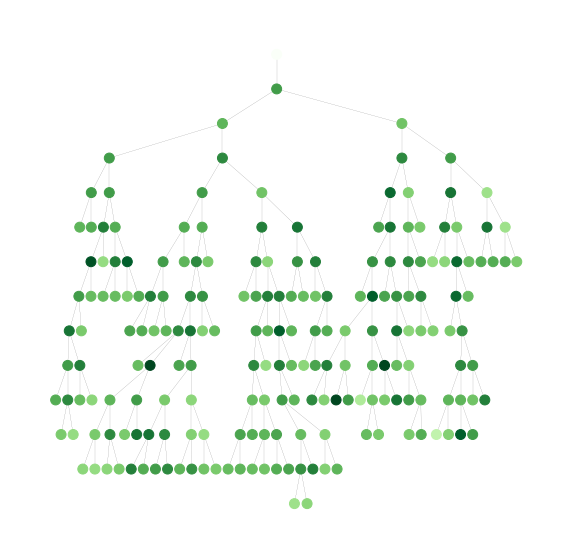

In [ ]:
%%julia 


# sizey=Int(ceil(max_lvl/10)*10)
# sizex=Int(round(n_cells*.25))
# println(sizex," ",sizey)
nsz=Int(round(10000/n_cells))
# println(nsz)


nodes_positions=ntx.nx_agraph.graphviz_layout(bs_G,prog= "dot",args="-Grankdir=TB -Gsplines=false -Gnodesep=.5 -Goverlap=scalexy",root=bs_roots[1])   #progs dot, twopi, fdp, sfdp, circo 

plt.figure(figsize=(10,10))
ax=ntx.draw_networkx(bs_G,nodes_positions,node_size=nsz,node_color=list_colorsC,width=0.1,arrowsize=7,font_size=8,arrows=false,with_labels=false)
plt.axis("off")
plt.show()

## Making Graph using all nodes and division events

In [ ]:
%%julia 

bs_GAC=make_Graph_All_and_Divisions(this_bst3,time_mins3)
list_colorsAC=get_node_colors(bs_GAC,max_plasmids)
list_sizesAC=get_node_sizes(bs_GAC);  


## Making Graph using all nodes 

In [ ]:
%%julia 

bs_GA=make_Graph_All(this_bst3,time_mins3)
list_colorsA=get_node_colorsSharp(bs_GA,min_plasmids,max_plasmids)
list_sizesA=get_node_sizes(bs_GA);

#### this part removes self connections "loops" created on division events
loops=[]
for (u,v) in bs_GA.edges
    u == v ?  push!(loops,u) : 0
    end
for l in loops
    bs_GA.remove_edge(l,l)
end

#### calculating node positions

In [ ]:
%%julia 

# sizey=Int(ceil(max_lvl/10)*10)
# sizex=Int(round(n_cells*.25))
# println(sizex," ",sizey)
nsz=Int(round(10000/n_cells))
# println(nsz)

nodes_positionsA=ntx.nx_agraph.graphviz_layout(bs_GA,prog= "dot",args="-Grankdir=TB -Gsplines=false -Gnodesep=.5 -Goverlap=scalexy",root="0-0")   #progs dot, twopi, fdp, sfdp, circo 

;

#### Finding dead cells ( tree leaves)

In [ ]:
%%julia 

startposy=[]
endposy=[]
for (k,v) in nodes_positionsA
    kid,kt=split(k,"-")
    x,y=v
    kt=parse(Int,kt)
    kt==Int(pulse_start*60) ? push!(startposy,y) : 0
    kt==Int(pulse_end*60) ? push!(endposy,y) : 0
end
pulse_ymin=minimum(endposy)
pulse_ymax=maximum(startposy)

leaves = []
dead_leaves=[]
alive_leaves=[]
for (v, d) in bs_GA.out_degree() 
    if d == 0
    push!(leaves,v)
        n,t=split(v,"-")
        parse(Int,t)<Int(pulse_end*60) ? push!(dead_leaves,v) : push!(alive_leaves,v)
    end 
end

dead_xs=[]
dead_ys=[]
for this_dead in dead_leaves
    xd,yd=nodes_positionsA[this_dead]
    push!(dead_xs,xd)
    push!(dead_ys,yd)
end




### calulating mmeassuremnts for plot aes

In [ ]:
%%julia 


xx,yy=nodes_positionsA["1-1"]
timeEndy=yy

y_ends=[]
for this_leave in alive_leaves
    xx,yy=nodes_positionsA[this_leave]
    push!(y_ends,yy)
end
time0y=mean(y_ends)
time0y,timeEndy

newtimeEndy=trunc(timeEndy/100)*100
println(newtimeEndy)

newticks=collect(0:newtimeEndy/10:newtimeEndy)
newticks=Int.(newticks)

timeticks=collect(0:30:time_mins3[end])
#push!(timeticks,Int(pulse_start*60))
#push!(timeticks,Int(pulse_end*60))
sort!(timeticks)

m=(0-newtimeEndy)/(time_mins3[end]-0)
b=newtimeEndy+300
f(x)=m*x+b

newticks2=[]
for t in timeticks
    yt=f(t)
    push!(newticks2,yt)
end
reverse!(newticks2)



22100.0

[300.0,
 2510.0,
 4720.0,
 6929.999999999998,
 9140.0,
 11350.0,
 13560.0,
 15770.0,
 17980.0,
 20190.0,
 22400.0]

Saving figure /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/Fig-7A.pdf ..


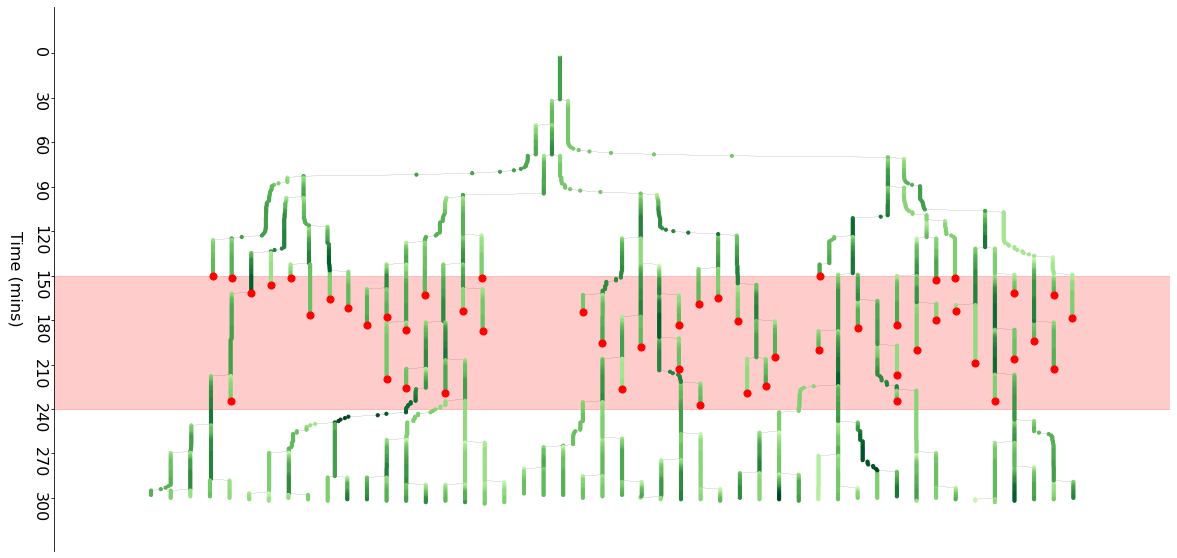

In [29]:
%%julia 

fig=plt.figure(figsize=(20,10))
fig.set_facecolor("white")
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["font.size"] = 16

ax=ntx.draw_networkx(bs_GA,nodes_positionsA,node_size=nsz./10,node_color=list_colorsA,width=0.1,arrowsize=7,font_size=8,arrows=false,with_labels=false)

#plt.axis("off")
axs = plt.gca()
axs.tick_params(left=true, bottom=false, labelleft=true, labelbottom=false)
#axs.tick_params(axis="both", left="off", top=false, right="off", bottom="off", labelleft="off", labeltop="off", labelright="off", labelbottom="off")

axs.set_yticks(newticks2)
newtickslabels=reverse(timeticks)
axs.set_yticklabels(newtickslabels,rotation=270)

axs.spines["right"].set_visible(false)
axs.spines["top"].set_visible(false)
axs.spines["bottom"].set_visible(false)


#axs.axhspan(ymin=pulse_ymin, ymax=pulse_ymax, xmin=0, xmax=1,color="red",alpha=0.2)
axs.axhspan(ymin=f(pulse_end*60), ymax=f(pulse_start*60), xmin=0, xmax=1,color="red",alpha=0.2)
axs.scatter(dead_xs,dead_ys,s=50,c="r",zorder=3)#,marker="x")
axs.set_ylabel("Time (mins)",rotation="270", labelpad=25)

#axs.scatter(xx,yy,s=50,c="r",zorder=3,marker="x")
#axs.axhline(y=144)
#axs.axhline(y=0)

#plt.tight_layout()

figname=pathFigures*"Fig-7A.pdf"
println("Saving figure $figname ..")
plt.savefig(figname,bbox_inches = "tight",pad_inches = 0.1)
plt.show()
